PROGRAMMA CHE RIPRENDE EMISSIONE DISCO MA SENZA FARE PROVE PER VEDERE CHE FUNZIONI
QUI lo si usa direttamente per confrontare Lion di certe transizioni con Llinea di quelle transizioni (quest'ultima ottenuta da Gabriele e riportata in unità di 10^42 erg/sec in Tabella_completa.csv). 
ATTENZIONE: questo processo vale per ogni blazar della lista, solo che non è detto che ogni blazar abbia tutte e stesse transizioni!

In [91]:
import numpy as np
import matplotlib.pyplot as plt

#parametri e costanti per il disco di accrescimento: c, G, h, kB, sigma, Msun

c = 2.99792458e10          # cm/s
G = 6.67430e-8             # unità cgs = cm^3 g^-1 s^-2
h = 6.62607015e-27         # erg*s  
kB = 1.380649e-16          # erg/K  #costante di Boltzmann
sigma = 5.670374419e-5     # erg cm^-2 s^-1 K^-4  #costante di Stefan-Boltzmann
Msun = 1.98847e33          # g

MBH = 1e8 * Msun           # massa del buco nero in grammi
eta = 0.083                #efficienza di conversione massa-energia  #0.083 meglio di 0.1, anche se 0.08 vuol dire che considera disco fermo, ma in realtà ruoterebbe
Ledd = 1.3e38 * (MBH / Msun)  # erg/s  
Ldisk = 0.1 * Ledd            # erg/s
Mdot = Ldisk / (eta * c**2)   # g/s  #tasso di accrescimento

Rs = 2 * G * MBH / c**2     # cm 
Rin = 3 * Rs                # raggio interno del disco
Rout = 3000 * Rs            # raggio esterno del disco

#printo il valore di Ldisk
print(f"Ldisk = {Ldisk:.3e} erg/s")

Ldisk = 1.300e+45 erg/s


In [92]:
# vettore dei raggi
Nr = 2000  # numero di punti radiali
R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)  # cm

# calcolo della temperatura in funzione della MBH, Mdot e R
f = 1.0 - np.sqrt(Rin / R)
f = np.clip(f, 0.0, None)  # evito valori negativi per R<Rin
T = ((3*G*MBH*Mdot)/(8*np.pi*sigma*R**3) * f)**0.25  # K

# vettore delle frequenze
Nnu = 400 # numero di punti in frequenza presi
nu = np.logspace(13, 17, Nnu)  # Hz     #meglio consideare fino a 10^17 soprattutto per quando calcolo le luminosità di ionizzazione delle linee 

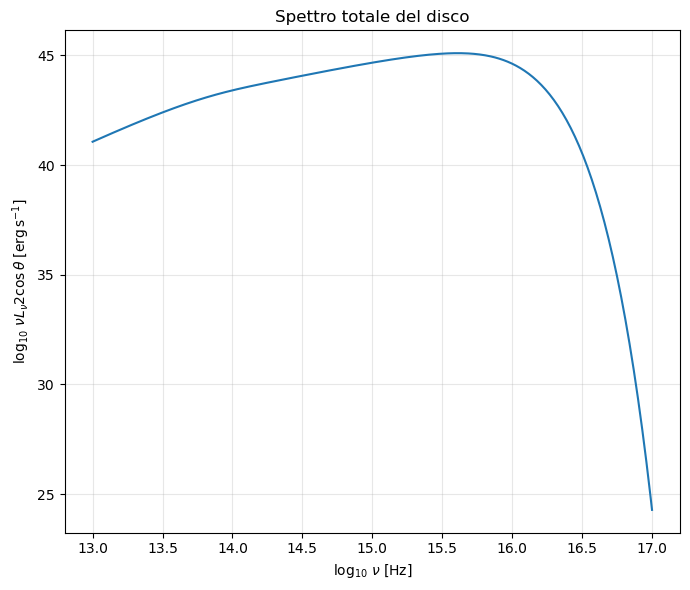

In [93]:
# inizializzo matrice Bnu con dimensioni (Nnu, Nr): righe=frequenze, colonne=raggi e quindi temperature
Bnu = np.zeros((Nnu, Nr))  

# calcolo di B_nu(nu, T) per ogni frequenza e temperatura
for j in range(Nr): #loop sui raggi
    x = h * nu / (kB * T[j])  #array di dimensione (Nnu,) con x per ogni frequenza a quel raggio
    x = np.clip(x, 1e-12, 700.0) # evito overflow per valori di x grandi 
    Bnu[:, j] = (2*h*nu**3 / c**2) / (np.exp(x) - 1.0) #calcolo di Bnu per ogni frequenza a quel raggio, memorizzato nella matrice Bnu

# calcolo di L(nu) integrando su R
integrand = R[None, :] * Bnu                  # ATT: se non metto none negli R si sballa perchè R è un array di dimensione (Nr,) e Bnu è (Nnu, Nr); con none invece R diventa (1, Nr), così integrand ha dimensione (Nnu, Nr)
I_nu = np.trapezoid(integrand, R, axis=1)     # integrale su R per ogni frequenza, restituisce un array di dimensione (Nnu,) con I_nu per ogni frequenza
Lnu = 4 * np.pi**2 * I_nu                     # L(nu) per ogni frequenza, array di dimensione (Nnu,)
nuLnu = nu * Lnu

theta = 3.0 * np.pi / 180.0  # angolo di osservazione del disco rispetto alla normale al disco che è verso di noi, in radianti (3 gradi)
#plot dello spettro totale del disco in forma nu*L(nu) vs nu
plt.figure(figsize=(7,6))
#calcolo nu*L(nu)*coseno dell'angolo theta definito prima
plt.plot(np.log10(nu), np.log10(nuLnu *2* np.cos(theta)), label=r'$L_\mathrm{disk} = 0.1 L_\mathrm{Edd}$')
plt.xlabel(r'$\log_{10}\,\nu \;[\mathrm{Hz}]$')
plt.ylabel(r'$\log_{10}\,\nu L_\nu 2\cos\theta \;[\mathrm{erg\,s^{-1}}]$')
plt.title('Spettro totale del disco')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [94]:
nu_max = 1e17  # Hz

#Lettura del file di dati 
data = np.genfromtxt("dati.asc", dtype=None, encoding="utf-8")

names, Eion, nu_ion_list = np.genfromtxt(     # data è shape (N,3)
    "dati.asc",
    dtype=('U20', float, float),
    unpack=True)


# Calcolo L_ion per ciascuna riga
Lion_list = []
for nu_ion in nu_ion_list:
    # Se nu_ion è sopra nu_max -> nessun contributo nel range scelto
    if nu_ion >= nu_max:
        Lion = 0.0
    else:
        mask = (nu >= nu_ion) & (nu <= nu_max)
        Lion = np.trapezoid(Lnu[mask], nu[mask])  # erg/s
    Lion_list.append(Lion)

Lion_list = np.array(Lion_list)

# Stampo tabellina
print("Transizione   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] ")
for n, E, nui, Li in zip(names, Eion, nu_ion_list, Lion_list):
    print(f"{n:>12}  {E:10.3g}  {nui:12.3e}  {Li:12.3e}  ")

Transizione   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] 
          Ha        1.89     4.600e+14     1.231e+45  
          Hb        2.55     6.200e+14     1.196e+45  
          Hg        2.86     6.910e+14     1.180e+45  
          Hd        3.02     7.370e+14     1.168e+45  
        MgII          15     3.630e+15     5.393e+44  
        CIII        54.4     1.315e+16     1.053e+43  
         CIV        47.9     1.158e+16     2.321e+43  
       Mg_pp        80.1     1.940e+16     5.854e+41  


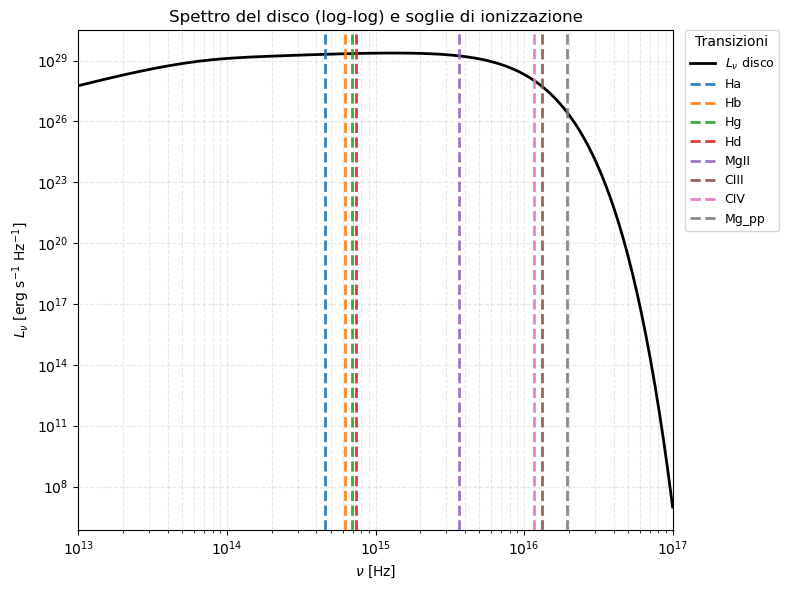

In [95]:
# Plot dello spettro del disco con le soglie di ionizzazione evidenziate
plt.figure(figsize=(8,6))

# curva del disco
plt.loglog(nu, Lnu, lw=2, color="k", label=r'$L_\nu$ disco')  #scala bilogaritmica per vedere meglio
#plt.plot(nu, Lnu, lw=2, color="k", label=r'$L_\nu$ disco')   #scala lineare


# colori diversi e assegnati esplicitamente
cmap = plt.get_cmap("tab10")  # 10 colori distinti (se ho più righe, dovrei passare a 'tab20')
colors = [cmap(i % cmap.N) for i in range(len(names))]

for (n, nui, col) in zip(names, nu_ion_list, colors):
    plt.axvline(nui, ls="--", lw=2, alpha=0.9, color=col, label=str(n))

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]')
plt.xlim(1e13, 1e17)
plt.title(r'Spettro del disco (log-log) e soglie di ionizzazione')
plt.grid(True, which="both", ls="--", alpha=0.3)

# legenda fuori dal grafico (così non copre la curva)
plt.legend(title="Transizioni", fontsize=9, title_fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

plt.tight_layout()
plt.show()

FINO A QUI UGUALE A disco.ipynb (senza le prove per vedere che modello funzioni)

ORA FACCIO lettura del file di Gabriele Tabella_completa.csv (che ho ridotto per i miei 13 blazar iniziali in Tab_completa_revisione.csv): decido che blazar prendere indicandone l'indice riga e me ne faccio stampare nome e redshift, trovo le transizioni e stampo la luminosità delle righe di emissione (diverse da 0)

In [96]:
import pandas as pd
df = pd.read_csv("Tab_completa_revisione.csv")

# seleziono il blazar che mi intereressa
row = df.iloc[11]
print("-"*50)
print("--Blazar selezionato:--")
print("Nome:", row.get("label", row.get("file_name", "??"))) #se c'è la colonna "label" la uso, altrimenti prendo "file_name", se non c'è neanche quella metto "??"
print("Redshift:", row.get("redshift", "??"))


# Trovo tutte le colonne *_norm
norm_columns = [col for col in df.columns if col.endswith("_norm")]

# Calcolo la luminosità di riga
print("-"*50)
print("--Luminosità delle righe (in erg/s):--")

for col in norm_columns:
    norm_value = row[col]

    # Se il valore è NaN o negativo lo salto
    if pd.isna(norm_value) or norm_value <= 0:
        continue

    L_line = norm_value * 1e42  # conversione in erg/s
    line_name = col.replace("_norm", "")
    print(f"{line_name:8s}  norm={norm_value:.3f}  -->  L_linea_{line_name} ={L_line:.3e} erg/s")
print("-"*50)

--------------------------------------------------
--Blazar selezionato:--
Nome: J0133.2-5159
Redshift: 0.925
--------------------------------------------------
--Luminosità delle righe (in erg/s):--
MgII      norm=71.539  -->  L_linea_MgII =7.154e+43 erg/s
Hd        norm=18.290  -->  L_linea_Hd =1.829e+43 erg/s
--------------------------------------------------


ORA 

In [ ]:
print("-"*50)   
print("--Confronto tra luminosità di riga e luminosità di ionizzazione:--")
for col in norm_columns:    #in questo loop: scorro linee emissione blazar, converto norm in luminosità di linea, cerco la transizione corrispondente in names per trovare L_ion e confronto i due valori
    norm_value = row[col]
    # Se il valore è NaN o negativo lo salto
    if pd.isna(norm_value) or norm_value <= 0:
        continue    
    L_line = norm_value * 1e42  # conversione in erg/s
    line_name = col.replace("_norm", "")
    # cerco la transizione corrispondente in names per trovare L_ion
    if line_name in names:
        idx = np.where(names == line_name)[0][0]
        L_ion = Lion_list[idx]
        print(f"{line_name:8s}  L_linea_{line_name}={L_line:.3e} erg/s,   L_ion_{line_name}={L_ion:.3e} erg/s")
    else:
        print(f"{line_name:8s}  L_linea_{line_name}={L_line:.3e} erg/s,   L_ion_{line_name}=?? (transizione non trovata)")
    # calcolo il rapporto L_line / L_ion per le linee per cui ho sia L_line che L_ion e lo interpreto come un "covering factor" che mi dice se L_line è compatibile con ionizzazione da parte del disco
    Covering_factor = L_line / L_ion if L_ion > 0 else np.nan
    print(f"        --> Covering factor (L_line / L_ion) = {Covering_factor:.3e}")
print("-"*50)


--------------------------------------------------
--Confronto tra luminosità di riga e luminosità di ionizzazione:--
MgII      L_linea_MgII=7.154e+43 erg/s,   L_ion_MgII=5.393e+44 erg/s
        --> Covering factor (L_line / L_ion) = 1.327e-01
Hd        L_linea_Hd=1.829e+43 erg/s,   L_ion_Hd=1.168e+45 erg/s
        --> Covering factor (L_line / L_ion) = 1.566e-02
--------------------------------------------------


TEORIA : Nei dischi di accrescimento degli AGN e dei blazar il gas caldo emette una grande quantità di radiazione ultravioletta ed estrema-ultravioletta. Tra questi fotoni ce ne sono alcuni con energia abbastanza alta da ionizzare gli atomi delle nubi di gas che circondano il buco nero (la Broad Line Region). Solo una frazione della radiazione intercetta davvero le nubi: è qui che entra in gioco il covering factor. I fotoni che vengono assorbiti depositano energia nel gas e producono elettroni liberi; il gas si riscalda e cambia stato di ionizzazione. Dopo l’ionizzazione, però, il sistema tende a tornare verso stati più stabili: gli elettroni liberi si ricombinano con gli ioni e gli atomi risultanti sono spesso in stati eccitati. Quando questi decadono verso livelli energetici più bassi emettono nuovi fotoni a frequenze ben precise: sono le righe di emissione.  
Non tutta l’energia ionizzante finisce nelle righe: una parte riscalda il gas, una parte esce come continuo ricombinante, e solo una frazione viene convertita in ciascuna linea specifica.


RICORDO COSA è IL COVERING FACTOR: misura quanta parte della radiazione del disco viene intercettata dal gas del BLR.  
In particolare:   
    Cf=0 --> nessuna nube davanti al disco   
    Cf=0.1 --> il 10% della rad incontra il BLR  
    Cf=1 --> gas circonda completamente la sorgente
NB: Questo (rapporto tra L_line e L_ion per una singola frequenza di ionizzazione) è davvero il covering factor ????

INVECE L_line/L_ion :  
    -se <<1 : (situa normale) disco produce abbastanza fotoni ionizzanti . Solo una piccola frazione finisce in quella riga.  
    -se =1 : quasi tutta la potenza ionizzante disponibile va in una sola riga. Questo è improbabile perché l'energia si distribuisce tra molte righe ed il continuo.
    Possibili cause: Mbh o Ldisk sbaglaiti nel modello, griglia in freq. troppo corta.  
    -se >1 : questo non è fisicamente possibile se il disco è l'unica sorgente ionizzante.

NB: ma quindi le luminosità di ionizzazione della riga i-esima sono uguali per ogni blazar ?!
(dato che il mio modello teorico di emissione (disco.ipynb)è sempre con stessa massa e raggi)

ORA calcolo la luminosità della BLR (potenza totale irradiata dalla Broad Line Region) e ricalcolo il covering factor

In [ ]:
L_lines = {}
L_BLR = 0.0

for col in norm_columns:
    norm_value = row[col]
    if pd.isna(norm_value) or norm_value <= 0:
        continue

    L_line = norm_value * 1e42
    line_name = col.replace("_norm", "")
    L_lines[line_name] = L_line
    L_BLR += L_line

print("-- Somma luminosità di riga --")
print(f"L_BLR = Sommatoria su i (L_line_i) = {L_BLR:.3e} erg/s  (N_righe={len(L_lines)})")

Cf_reale = L_BLR / Ldisk if Ldisk > 0 else np.nan
print(f"Covering factor totale (L_BLR / L_disk) = {Cf_reale:.3e}")

-- Somma luminosità di riga --
L_BLR = Sommatoria su i (L_line_i) = 8.983e+43 erg/s  (N_righe=2)
Covering factor totale (L_BLR / L_disk) = 6.910e-02
